## Analyse network data

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os

In [13]:
if not os.path.exists('../result/cleaned/Network datatset'):
    os.makedirs('../result/cleaned/Network datatset')

In [14]:
# Open attack.cs
df_attack = pd.read_csv('../data/Network datatset/csv/attack_4.csv', delimiter=',', header=0)
# 5527409 rows attack_1
# 5159469 rows attack_2
# 5862547 rows attack_3
# 5522490 rows attack_4

In [15]:
df_attack = df_attack.drop_duplicates()

In [16]:
print(df_attack.shape)
print(df_attack.columns)

(5131109, 16)
Index(['Time', 'mac_s', 'mac_d', 'ip_s', 'ip_d', 'sport', 'dport', 'proto',
       'flags', 'size', 'modbus_fn', 'modbus_response', 'n_pkt_src',
       'n_pkt_dst', 'label_n', 'label'],
      dtype='object')


In [17]:
# Change the name of the columns by removing the spaces
df_attack.columns = df_attack.columns.str.replace(' ', '')

In [18]:
print("Number of rows before droping: ", len(df_attack))
column_NaN = ['Time','mac_s', 'mac_d', 'ip_s', 'ip_d', 'sport', 'dport', 'flags', 'proto', 'size', 'n_pkt_src', 'n_pkt_dst', 'label']
df_attack = df_attack.dropna(subset=column_NaN)
print("Number of rows after droping: ", len(df_attack))

Number of rows before droping:  5131109
Number of rows after droping:  4350185


In [19]:
def get_columns_info(column_name):
    print('Column name: ', column_name)
    print('Number of unique values in attack: ', df_attack[column_name].nunique())
    print('Number of missing values in attack: ', df_attack[column_name].isnull().sum())
    print('Number of values in attack: ', df_attack[column_name].count())
    print('Values in attack: ', df_attack[column_name].unique())
    print('Values count: ', df_attack[column_name].value_counts())

# Début Rapport d'analyse

problème avec ces colonne : 'ip_s', 'ip_d', 'sport', 'dport', 'flags', 'n_pkt_src', 'n_pkt_dst', 'modbus_fn', 'modbus_response'
raison : missing some values

problème avec modbus_fn, lot of missing value (153121 for attack1), useless column ? Même chose avec modbus_response : Colonne lié au proto modbus et donc pas toute les colonne

La colonne proto contient les protocoles ARP ICMP Modbus TCP pour attack mais seulement Modbus et TCP pour le cas normal

Problème de typage : 'sport', 'dport', 'flags', 'n_pkt_src', 'n_pkt_dst'

Certaine dates sont partagé pour plusieurs entrées (ex : 2021-04-09 18:42:46.997219 a 4 entrés)

Le s dans ip_s, sport est pour source et le d pour destination

Il y a des cas noté normaux dans les csv attack, besoin du csv normal ?

different types d'attaques : 

 - ['normal' 'anomaly' 'MITM' 'physical fault'] pour attack_1
 - ['normal' 'physical fault' 'anomaly' 'DoS' 'MITM'] pour attack_3
 - ['normal' 'scan' 'DoS' 'physical fault' 'MITM'] pour attack_4 et attack_2


In [20]:
get_columns_info('label_n')
get_columns_info('label')

Column name:  label_n
Number of unique values in attack:  2
Number of missing values in attack:  0
Number of values in attack:  4350185
Values in attack:  [0 1]
Values count:  label_n
0    2844877
1    1505308
Name: count, dtype: int64
Column name:  label
Number of unique values in attack:  5
Number of missing values in attack:  0
Number of values in attack:  4350185
Values in attack:  ['normal' 'scan' 'DoS' 'physical fault' 'MITM']
Values count:  label
normal            2844877
DoS                732749
MITM               471241
physical fault     301287
scan                   31
Name: count, dtype: int64


In [21]:
# Conversion des types de données
column_type = ['sport', 'dport', 'flags', 'n_pkt_src', 'n_pkt_dst']
for column in column_type:
    df_attack[column] = df_attack[column].astype('int64')

# On retire les brackets [ ] et on convertit en float64, puis on remplace les NaN par -1 et on convertit en int64

df_attack['modbus_response'] = df_attack['modbus_response'].str.replace('[', '', regex=False).str.replace(']', '', regex=False)
df_attack['modbus_response'] = pd.to_numeric(df_attack['modbus_response'], errors='coerce').fillna(-1).astype('int64')

In [22]:
df_attack['Time'] = pd.to_datetime(df_attack['Time'], errors='coerce')

In [23]:
# Conversion en catégories des colonnes proto, flags, label et modbus_fn
df_attack['proto'] = df_attack['proto'].astype('category')
df_attack['flags'] = df_attack['flags'].astype('category')
df_attack['label'] = df_attack['label'].astype('category')
df_attack['modbus_fn'] = df_attack['modbus_fn'].astype('category')

In [29]:
# Save
df_attack.to_csv('../result/cleaned/Network datatset/attack_4_cleaned.csv', index=False)

In [30]:
df_attack.shape

(4350185, 16)

# Test part from here, will be move to a different file

In [31]:
# Analyse exploratoire des données (EDA)
print("Aperçu des données nettoyées :\n", df_attack.head())
print("\nDescription statistique :\n", df_attack.describe(include='all'))

Aperçu des données nettoyées :
                         Time              mac_s              mac_d  \
0 2022-02-21 14:45:25.454111  74:46:a0:bd:a7:1b  e6:3f:ac:c9:a8:8c   
1 2022-02-21 14:45:25.454114  74:46:a0:bd:a7:1b  fa:00:bc:90:d7:fa   
2 2022-02-21 14:45:25.454142  74:46:a0:bd:a7:1b  0a:fe:ec:47:74:fb   
3 2022-02-21 14:45:25.454260  00:80:f4:03:fb:12  74:46:a0:bd:a7:1b   
4 2022-02-21 14:45:25.454365  e6:3f:ac:c9:a8:8c  74:46:a0:bd:a7:1b   

           ip_s          ip_d  sport  dport   proto  flags  size  \
0   84.3.251.20  84.3.251.101  60614    502  Modbus  11000    66   
1   84.3.251.20  84.3.251.103  60616    502  Modbus  11000    66   
2   84.3.251.20  84.3.251.102  60615    502  Modbus  11000    66   
3   84.3.251.18   84.3.251.20    502  60523     TCP  11000   109   
4  84.3.251.101   84.3.251.20    502  60614  Modbus  11000    65   

                         modbus_fn  modbus_response  n_pkt_src  n_pkt_dst  \
0           Read Holding Registers               -1          

In [32]:
# KNN algorithm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

In [37]:
# Load the cleaned dataframes

df_attack = pd.read_csv('../result/cleaned/Network datatset/attack_2_cleaned.csv', delimiter=',', header=0)

FileNotFoundError: [Errno 2] No such file or directory: '../result/cleaned/Network datatset/attack_2_cleaned.csv'

In [39]:
df_attack.columns

Index(['Time', 'mac_s', 'mac_d', 'ip_s', 'ip_d', 'sport', 'dport', 'proto',
       'flags', 'size', 'modbus_fn', 'modbus_response', 'n_pkt_src',
       'n_pkt_dst', 'label_n', 'label'],
      dtype='object')

In [38]:
import matplotlib.pyplot as plt

# Subset of normal and attack dataframes
df_label1 = df_attack[df_attack['label_n'] == 1]
df_label0 = df_attack[df_attack['label_n'] == 0]

In [40]:
proto1 = df_label1['proto'].value_counts(normalize=True)
print(proto1)

proto0 = df_label0['proto'].value_counts(normalize=True)
print(proto0)

mac_s1 = df_label1['mac_s'].value_counts(normalize=True)
print(mac_s1)

mac_s0 = df_label0['mac_s'].value_counts(normalize=True)
print(mac_s0)

mac_d1 = df_label1['mac_d'].value_counts(normalize=True)
print(mac_d1)

mac_d0 = df_label0['mac_d'].value_counts(normalize=True)
print(mac_d0)

ip_s1 = df_label1['ip_s'].value_counts(normalize=True)
print(ip_s1)

ip_s0 = df_label0['ip_s'].value_counts(normalize=True)
print(ip_s0)

# Rien de spécial entre attack et normal

proto
Modbus    0.708594
TCP       0.291406
Name: proportion, dtype: float64
proto
Modbus    0.950461
TCP       0.049539
Name: proportion, dtype: float64
mac_s
74:46:a0:bd:a7:1b    0.361228
00:0c:29:47:8c:0e    0.256996
e6:3f:ac:c9:a8:8c    0.113470
0a:fe:ec:47:74:fb    0.112124
fa:00:bc:90:d7:fa    0.111173
00:80:f4:03:fb:12    0.041707
fe:bb:16:7b:c3:27    0.001661
4a:35:83:e0:3d:a4    0.001642
Name: proportion, dtype: float64
mac_s
74:46:a0:bd:a7:1b    0.484809
e6:3f:ac:c9:a8:8c    0.152457
0a:fe:ec:47:74:fb    0.149904
fa:00:bc:90:d7:fa    0.148591
00:80:f4:03:fb:12    0.058928
4a:35:83:e0:3d:a4    0.002656
fe:bb:16:7b:c3:27    0.002655
Name: proportion, dtype: float64
mac_d
74:46:a0:bd:a7:1b    0.363637
00:80:f4:03:fb:12    0.295306
e6:3f:ac:c9:a8:8c    0.113753
0a:fe:ec:47:74:fb    0.112491
fa:00:bc:90:d7:fa    0.111135
fe:bb:16:7b:c3:27    0.001265
4a:35:83:e0:3d:a4    0.001260
00:0c:29:47:8c:0e    0.001153
Name: proportion, dtype: float64
mac_d
74:46:a0:bd:a7:1b    0.483082
e6:

n_pkt_src
97    0.099910
14    0.099840
50    0.084052
15    0.071240
49    0.055094
13    0.050538
98    0.046032
96    0.037188
51    0.034220
99    0.027248
Name: proportion, dtype: float64


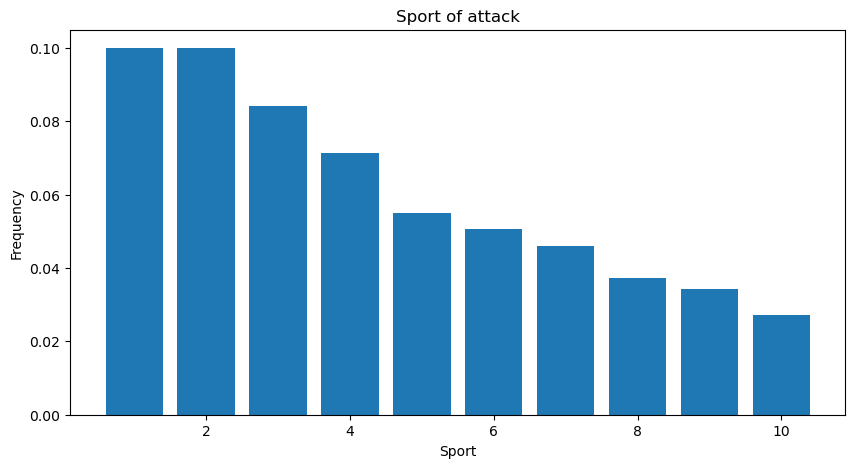

In [41]:
# Plot first 10 sport of attack
sport1 = df_label1['n_pkt_src'].value_counts(normalize=True).head(10)
print(sport1)
# Change index of sport1 to 1 to 5
sport1.index = range(1, 11)
plt.figure(figsize=(10, 5))
plt.bar(sport1.index, sport1.values)
plt.title('Sport of attack')
plt.xlabel('Sport')
plt.ylabel('Frequency')
plt.show()


n_pkt_src
14    0.199272
50    0.165029
15    0.134981
49    0.106281
51    0.064781
13    0.036264
48    0.031812
44    0.026758
45    0.020228
43    0.018352
Name: proportion, dtype: float64


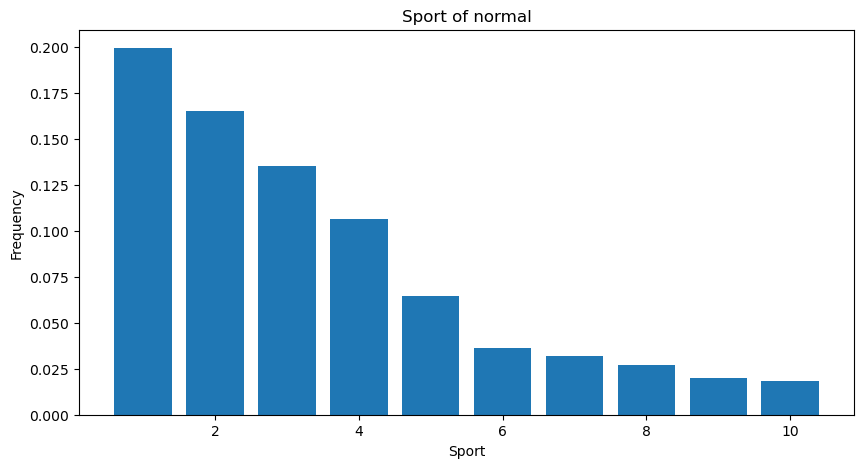

In [42]:
# Plot first 10 sport of attack
sport1 = df_label0['n_pkt_src'].value_counts(normalize=True).head(10)
print(sport1)
# Change index of sport1 to 1 to 5
sport1.index = range(1, 11)
plt.figure(figsize=(10, 5))
plt.bar(sport1.index, sport1.values)
plt.title('Sport of normal')
plt.xlabel('Sport')
plt.ylabel('Frequency')
plt.show()

In [43]:
# Find the range of Date : '2021-04-19 15:37:19.989214' to '2021-04-19 16:12:14.167723'
df_attack.head(30)

,Time,mac_s,mac_d,ip_s,ip_d,sport,dport,proto,flags,size,modbus_fn,modbus_response,n_pkt_src,n_pkt_dst,label_n,label
0,2022-02-21 14:45:25.454111,74:46:a0:bd:a7:1b,e6:3f:ac:c9:a8:8c,84.3.251.20,84.3.251.101,60614,502,Modbus,11000,66,Read Holding Registers,-1,0,0,0,normal
1,2022-02-21 14:45:25.454114,74:46:a0:bd:a7:1b,fa:00:bc:90:d7:fa,84.3.251.20,84.3.251.103,60616,502,Modbus,11000,66,Read Holding Registers,-1,1,0,0,normal
2,2022-02-21 14:45:25.454142,74:46:a0:bd:a7:1b,0a:fe:ec:47:74:fb,84.3.251.20,84.3.251.102,60615,502,Modbus,11000,66,Read Holding Registers,-1,2,0,0,normal
3,2022-02-21 14:45:25.454260,00:80:f4:03:fb:12,74:46:a0:bd:a7:1b,84.3.251.18,84.3.251.20,502,60523,TCP,11000,109,NaN,-1,0,0,0,normal
4,2022-02-21 14:45:25.454365,e6:3f:ac:c9:a8:8c,74:46:a0:bd:a7:1b,84.3.251.101,84.3.251.20,502,60614,Modbus,11000,65,Read Holding Registers Response,0,0,1,0,normal
5,2022-02-21 14:45:25.454415,0a:fe:ec:47:74:fb,74:46:a0:bd:a7:1b,84.3.251.102,84.3.251.20,502,60615,Modbus,11000,65,Read Holding Registers Response,0,0,2,0,normal
6,2022-02-21 14:45:25.454416,fa:00:bc:90:d7:fa,74:46:a0:bd:a7:1b,84.3.251.103,84.3.251.20,502,60616,Modbus,11000,65,Read Holding Registers Response,0,0,3,0,normal
7,2022-02-21 14:45:25.454720,00:80:f4:03:fb:12,74:46:a0:bd:a7:1b,84.3.251.18,84.3.251.20,502,60613,Modbus,11000,64,Read Coils Response,0,1,4,0,normal
8,2022-02-21 14:45:25.457141,74:46:a0:bd:a7:1b,e6:3f:ac:c9:a8:8c,84.3.251.20,84.3.251.101,60614,502,Modbus,11000,66,Read Holding Registers,-1,3,1,0,normal
9,2022-02-21 14:45:25.457143,74:46:a0:bd:a7:1b,0a:fe:ec:47:74:fb,84.3.251.20,84.3.251.102,60615,502,Modbus,11000,66,Read Holding Registers,-1,4,1,0,normal
